# Using `show_interactive_fin_flow_diag` to visualize financial flows

This notebook demonstrates how to use the `show_interactive_fin_flow_diag` function from `evbeantools.juptools` to create an interactive [Sankey diagram](https://plotly.com/python/sankey-diagram/) that visualizes the flow of money between accounts in a beancount ledger.

The Sankey diagram shows how money flows from source accounts (e.g. Income) through intermediary accounts (e.g. Assets) to destination accounts (e.g. Expenses). Each account type is color-coded:
- **Income** — orange
- **Expenses** — purple
- **Assets** — blue
- **Liabilities** — red
- **Equity** — green

## Notebook preparation

In [1]:
from beancount.loader import load_string

from evbeantools.juptools import get_sankey_figure_from_entries, show_interactive_fin_flow_diag



In [2]:
import plotly.io as pio
# pio.renderers.default = "notebook_connected"
pio.renderers.default = "png"

## Financial flow for simple cases

Before diving into the full interactive widget, let's see how the underlying Sankey diagram works on an almost minimal ledger.

Salary is being paid to the  `Income:Salary` and gets put to `Assets:Cash`. Then expenses to 2 different `Expenses` accounts are paid with cash

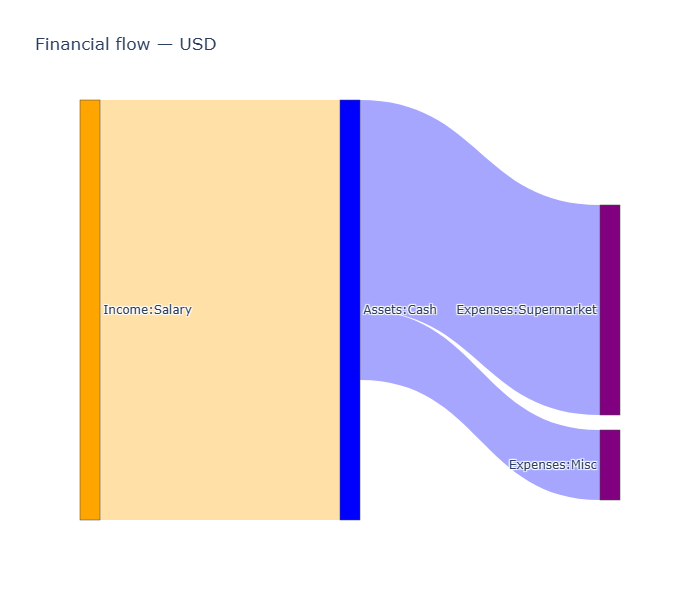

In [3]:
simple_ledger_2 = """\
option "operating_currency" "USD"

2023-01-01 open Assets:Cash
2023-01-01 open Income:Salary
2023-01-01 open Expenses:Supermarket
2023-01-01 open Expenses:Misc

2023-01-15 * "Salary"
    Assets:Cash                150 USD
    Income:Salary

2023-01-20 * "Buying things"
    Assets:Cash               -100 USD
    Expenses:Supermarket        75 USD
    Expenses:Misc               25 USD
"""

simple_entries_2, _, _ = load_string(simple_ledger_2)

fig = get_sankey_figure_from_entries(simple_entries_2, "USD")
fig.show()

## How `show_interactive_fin_flow_diag` works

`show_interactive_fin_flow_diag` takes two inputs:

1. **`entries`** — a list of beancount entries (as returned by `load_string` or `load_file`).
2. **`currencies`** — a list of currency strings (e.g. `["USD"]`). The first currency is selected by default in the interactive dropdown.

The function renders an interactive widget with the following controls:
- **Currency dropdown** — select which currency's flows to visualize.
- **Date range** — filter transactions by start/end date using date pickers and a range slider.
- **Account depth sliders** — control how many hierarchy levels to show for each account type (Income, Expenses, Assets, Equity, Liabilities). Lower values group sub-accounts together.

The Sankey diagram updates automatically when any control is changed.

## Define and load a demo ledger

We create a small beancount ledger inline that models a simple personal finance scenario over two years, with:
- **Income** from salary and freelance work
- **Expenses** for food, housing, transport, and entertainment
- **Assets** in a bank checking account and a savings account
- **Equity** for the opening balance
- **Liabilities** for a credit card

In [4]:
ledger = """\
option "operating_currency" "USD"

; --- Accounts ---
2023-01-01 open Assets:Bank:Checking
2023-01-01 open Assets:Bank:Savings
2023-01-01 open Liabilities:CreditCard
2023-01-01 open Income:Salary
2023-01-01 open Income:Freelance
2023-01-01 open Expenses:Food:Groceries
2023-01-01 open Expenses:Food:Restaurant
2023-01-01 open Expenses:Housing:Rent
2023-01-01 open Expenses:Housing:Utilities
2023-01-01 open Expenses:Transport:Fuel
2023-01-01 open Expenses:Transport:PublicTransport
2023-01-01 open Expenses:Entertainment:Movies
2023-01-01 open Expenses:Entertainment:Books
2023-01-01 open Equity:Opening-Balances

; --- Opening balance ---
2023-01-01 * "Opening Balance"
    Assets:Bank:Checking       10000 USD
    Equity:Opening-Balances

; ---- 2023 transactions ----
2023-01-31 * "January Salary"
    Assets:Bank:Checking        5000 USD
    Income:Salary

2023-02-15 * "Freelance project"
    Assets:Bank:Checking        1200 USD
    Income:Freelance

2023-02-20 * "Supermarket"
    Expenses:Food:Groceries      350 USD
    Assets:Bank:Checking

2023-03-01 * "Monthly rent"
    Expenses:Housing:Rent       1500 USD
    Assets:Bank:Checking

2023-03-15 * "Electric bill"
    Expenses:Housing:Utilities   120 USD
    Assets:Bank:Checking

2023-04-10 * "Dinner out"
    Expenses:Food:Restaurant     80 USD
    Liabilities:CreditCard

2023-04-20 * "Pay credit card"
    Liabilities:CreditCard       80 USD
    Assets:Bank:Checking

2023-05-01 * "Gas station"
    Expenses:Transport:Fuel      90 USD
    Assets:Bank:Checking

2023-05-15 * "Bus pass"
    Expenses:Transport:PublicTransport  45 USD
    Assets:Bank:Checking

2023-06-01 * "Cinema tickets"
    Expenses:Entertainment:Movies  30 USD
    Assets:Bank:Checking

2023-06-10 * "Bookstore"
    Expenses:Entertainment:Books   25 USD
    Assets:Bank:Checking

2023-06-30 * "Transfer to savings"
    Assets:Bank:Savings          2000 USD
    Assets:Bank:Checking

2023-07-31 * "July Salary"
    Assets:Bank:Checking        5000 USD
    Income:Salary

2023-08-20 * "Supermarket"
    Expenses:Food:Groceries      400 USD
    Assets:Bank:Checking

2023-09-01 * "Monthly rent"
    Expenses:Housing:Rent       1500 USD
    Assets:Bank:Checking

2023-10-15 * "Freelance project"
    Assets:Bank:Checking         800 USD
    Income:Freelance

2023-11-10 * "Restaurant"
    Expenses:Food:Restaurant     120 USD
    Liabilities:CreditCard

2023-11-25 * "Pay credit card"
    Liabilities:CreditCard       120 USD
    Assets:Bank:Checking

2023-12-01 * "Gas station"
    Expenses:Transport:Fuel      100 USD
    Assets:Bank:Checking

; ---- 2024 transactions ----
2024-01-31 * "January Salary"
    Assets:Bank:Checking        5200 USD
    Income:Salary

2024-02-20 * "Supermarket"
    Expenses:Food:Groceries      380 USD
    Assets:Bank:Checking

2024-03-01 * "Monthly rent"
    Expenses:Housing:Rent       1500 USD
    Assets:Bank:Checking

2024-03-18 * "Electric bill"
    Expenses:Housing:Utilities   140 USD
    Assets:Bank:Checking

2024-04-05 * "Freelance project"
    Assets:Bank:Checking        1500 USD
    Income:Freelance

2024-05-12 * "Dinner out"
    Expenses:Food:Restaurant     95 USD
    Liabilities:CreditCard

2024-05-20 * "Pay credit card"
    Liabilities:CreditCard       95 USD
    Assets:Bank:Checking

2024-06-01 * "Bus pass"
    Expenses:Transport:PublicTransport  50 USD
    Assets:Bank:Checking

2024-06-15 * "Cinema"
    Expenses:Entertainment:Movies  35 USD
    Assets:Bank:Checking

2024-06-30 * "Transfer to savings"
    Assets:Bank:Savings          3000 USD
    Assets:Bank:Checking
"""

entries, errors, options = load_string(ledger)

CURR = options["operating_currency"][0]
print(f"Operating currency: {CURR}")
print(f"Number of entries: {len(entries)}")
print(f"Errors: {errors}")

Operating currency: USD
Number of entries: 44
Errors: []


## Show the interactive financial flow diagram

Call `show_interactive_fin_flow_diag` with the loaded entries and the operating currency.

The widget that appears lets you:
- **Select a currency** from the dropdown (our ledger only uses USD).
- **Pick a date range** with the date pickers or the range slider.
- **Adjust account depth** for each account type (Income, Expenses, Assets, Equity, Liabilities) to collapse or expand sub-accounts in the Sankey diagram.

In [5]:
show_interactive_fin_flow_diag(entries, options["operating_currency"])

## Summary

1. **Load** a beancount ledger with `load_string` (or `load_file` for an existing `.beancount` file).
2. **Call** `show_interactive_fin_flow_diag(entries, currencies)` to launch the interactive Sankey widget.
3. **Explore** your financial flows by adjusting the date range, currency, and account‑depth sliders.

The Sankey diagram makes it easy to see where money comes from, where it goes, and how it moves between account types.